<a href="https://colab.research.google.com/github/ajtony3000/automated-intraOT-anesthesia-delivery/blob/main/Anesthesia_TCI_Simulatoripynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

╔══════════════════════════════════════════════════════════════╗
║   ADVANCED CLOSED-LOOP TCI (WITH PK/PD MODELING)             ║
╠══════════════════════════════════════════════════════════════╣
║  INDUCTION: 81.2mg  |  Cp: 0.28 ug/mL  |  Ce: 0.28 ug/mL ║
╚══════════════════════════════════════════════════════════════╝
Time: T+426s  |  Status: [GREEN] LIGHT: Dose +20%


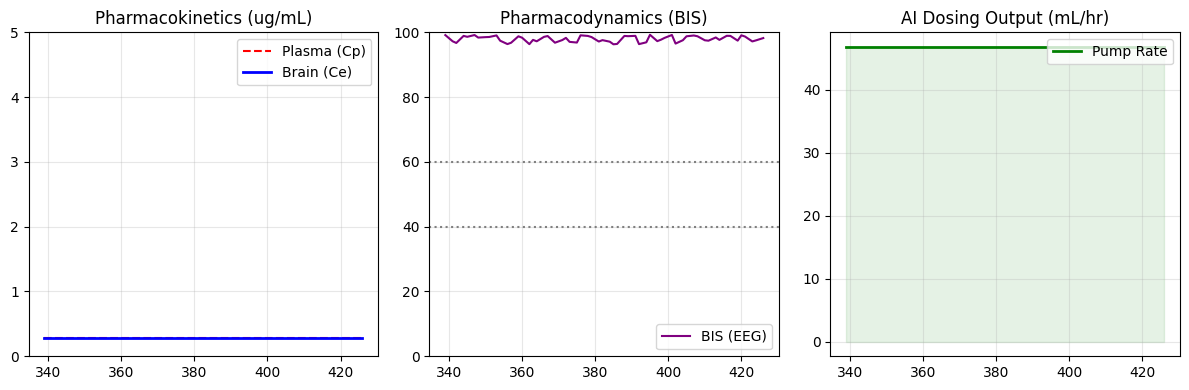

In [ ]:
import time
import math
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ==========================================
# 1. THE BRAIN: 4-PHASE TCI CONTROLLER
# ==========================================
class AnesthesiaAutomator:
    def __init__(self, age, weight, height, sex, baseline_hrv):
        self.weight = weight
        if sex.lower() == 'female':
            self.lbm = (1.07 * weight) - 148 * ((weight / height) ** 2)
        else:
            self.lbm = (1.1 * weight) - 128 * ((weight / height) ** 2)

        self.current_rate_ml_hr = 0.0
        self.start_time = None
        self.last_adjustment_time = 0
        self.refractory_period = 10
        self.baseline_hrv = baseline_hrv

    def calculate_induction_bolus_mg(self):
        return 1.8 * self.lbm # mg of Propofol

    def master_controller(self, inputs):
        if self.start_time is None: self.start_time = time.time()

        # [ PHASE 1 & 2: VETO & ARTIFACTS ]
        if inputs['EtCO2'] < 20 or inputs['SpO2'] < 88 or inputs['MAP'] < 55:
            self.current_rate_ml_hr = 0.0
            return 0.0, "CRITICAL: HARD STOP", "red"

        acc_mag = math.sqrt(inputs['acc_x']**2 + inputs['acc_y']**2 + inputs['acc_z']**2)
        if acc_mag > 1.2:
            return self.current_rate_ml_hr, "ARTIFACT: Holding Dose", "orange"

        # [ PHASE 3: CONTEXT MODIFIERS ]
        elapsed = time.time() - self.start_time
        base_rate = ((10 if elapsed < 20 else 8 if elapsed < 40 else 6) * self.weight) / 10
        modifier = 1.0

        if inputs['Temp'] < 37.0: modifier -= (0.07 * (37.0 - inputs['Temp']))
        if inputs['CVP'] < 5: modifier -= 0.20
        target_rate = base_rate * max(0.1, modifier)

        # [ PHASE 4: DOSING CONTROL ]
        msg = "Stable Target"
        status_color = "green"
        can_adjust = (time.time() - self.last_adjustment_time) > self.refractory_period

        if ((self.baseline_hrv - inputs['RMSSD']) / self.baseline_hrv) > 0.30 and can_adjust:
            target_rate *= 1.30
            self.last_adjustment_time = time.time()
            msg = "PAIN: Dose +30%"
            status_color = "yellow"
        elif inputs['BIS'] > 60:
            target_rate *= 1.20
            msg = "LIGHT: Dose +20%"
        elif inputs['BIS'] < 40:
            target_rate *= 0.70
            msg = "DEEP: Dose -30%"

        self.current_rate_ml_hr = target_rate
        return target_rate, msg, status_color

# ==========================================
# 2. THE PATIENT: PK/PD SIMULATOR
# ==========================================
class VirtualPatient:
    def __init__(self):
        # 1-Compartment PK Model Parameters (Schnider approximated)
        self.TIME_SCALE = 15  # Speed up time 15x for the 60-second visual demo
        self.k10 = 0.00738 * self.TIME_SCALE # Elimination rate (sec^-1)
        self.ke0 = 0.0076 * self.TIME_SCALE  # Effect-site delay (sec^-1)
        self.V1 = 4.27 # Central Volume (Liters)

        # Drug States
        self.M1 = 0.0  # Mass in central compartment (mg)
        self.Cp = 0.0  # Plasma Concentration (ug/mL)
        self.Ce = 0.0  # Effect-Site Concentration (ug/mL)

        self.vitals = {
            "HR": 75.0, "SpO2": 99.0, "MAP": 85.0, "EtCO2": 38.0,
            "RMSSD": 50.0, "BIS": 98.0, "acc_x": 0.0, "acc_y": 0.0,
            "acc_z": 1.0, "TOF_Count": 0, "Temp": 37.0, "CVP": 10.0
        }

    def update(self, pump_rate_ml_hr, bolus_mg=0.0, event_type=None):
        # --- 1. PHARMACOKINETICS (PK) ---
        dose_mg_sec = (pump_rate_ml_hr * 10) / 3600 # 1% Propofol is 10mg/mL

        # Mass balance in central compartment
        self.M1 += (dose_mg_sec + bolus_mg) - (self.k10 * self.M1)
        self.Cp = self.M1 / self.V1 # mg/L is equivalent to ug/mL

        # Effect-site equilibration (The Ke0 Delay)
        self.Ce += self.ke0 * (self.Cp - self.Ce)

        # --- 2. PHARMACODYNAMICS (PD: Emax Hill Equation) ---
        E0 = 98.0  # Awake BIS
        Emax = 88.0 # Max suppression (BIS ~10)
        EC50 = 3.0 # Ce required for 50% effect (ug/mL)
        gamma = 2.5 # Steepness of the dose-response curve

        target_bis = E0 - (Emax * (self.Ce**gamma) / (self.Ce**gamma + EC50**gamma))
        self.vitals["BIS"] = target_bis + random.uniform(-1.5, 1.5) # Add EEG noise

        # --- 3. VITAL SIGNS DRIFT & EVENTS ---
        self.vitals["HR"] += random.uniform(-1, 1)
        self.vitals["RMSSD"] += random.uniform(-1, 1)

        if event_type == "PAIN":
            self.vitals["RMSSD"] -= 5.0
            self.vitals["HR"] += 2.0
        elif event_type == "RESET":
            self.vitals["RMSSD"] = 50.0

        self.vitals["RMSSD"] = max(10, self.vitals["RMSSD"])
        return self.vitals

# ==========================================
# 3. THE UI: 3-PANEL DASHBOARD
# ==========================================
def run_dashboard_simulation():
    automator = AnesthesiaAutomator(45, 65, 160, 'female', baseline_hrv=50)
    patient = VirtualPatient()

    bolus_mg = automator.calculate_induction_bolus_mg()
    bolus_given = False

    history = {"time": [], "bis": [], "cp": [], "ce": [], "pump": []}
    start_sim = time.time()

    try:
        while True:
            elapsed = int(time.time() - start_sim)
            event = "PAIN" if 25 <= elapsed < 35 else ("RESET" if elapsed == 35 else None)

            # Give bolus only on the first second
            current_bolus = bolus_mg if not bolus_given else 0.0
            bolus_given = True

            # Control Loop Update
            rate, msg, status_color = automator.master_controller(patient.vitals)
            inputs = patient.update(rate, current_bolus, event)

            # Logging
            history["time"].append(elapsed)
            history["bis"].append(inputs["BIS"])
            history["cp"].append(patient.Cp)
            history["ce"].append(patient.Ce)
            history["pump"].append(rate)

            if len(history["time"]) > 60:
                for k in history: history[k].pop(0)

            # --- RENDER UI ---
            clear_output(wait=True)
            print(f"╔══════════════════════════════════════════════════════════════╗")
            print(f"║   ADVANCED CLOSED-LOOP TCI (WITH PK/PD MODELING)             ║")
            print(f"╠══════════════════════════════════════════════════════════════╣")
            print(f"║  INDUCTION: {bolus_mg:.1f}mg  |  Cp: {patient.Cp:.2f} ug/mL  |  Ce: {patient.Ce:.2f} ug/mL ║")
            print(f"╚══════════════════════════════════════════════════════════════╝")
            print(f"Time: T+{elapsed}s  |  Status: [{status_color.upper()}] {msg}")

            # --- PLOTTING ---
            plt.figure(figsize=(12, 4))

            # Plot 1: Drug Concentrations (The PK)
            plt.subplot(1, 3, 1)
            plt.plot(history["time"], history["cp"], label="Plasma (Cp)", color="red", linestyle="--")
            plt.plot(history["time"], history["ce"], label="Brain (Ce)", color="blue", linewidth=2)
            plt.title("Pharmacokinetics (ug/mL)")
            plt.ylim(0, max(5, max(history["cp"])+1))
            plt.grid(True, alpha=0.3); plt.legend(loc="upper right")

            # Plot 2: Brain Effect (The PD)
            plt.subplot(1, 3, 2)
            plt.plot(history["time"], history["bis"], label="BIS (EEG)", color="purple")
            plt.axhline(y=40, color='gray', linestyle='dotted')
            plt.axhline(y=60, color='gray', linestyle='dotted')
            plt.title("Pharmacodynamics (BIS)")
            plt.ylim(0, 100)
            plt.grid(True, alpha=0.3); plt.legend(loc="lower right")

            # Plot 3: Pump Output
            plt.subplot(1, 3, 3)
            plt.plot(history["time"], history["pump"], label="Pump Rate", color="green", linewidth=2)
            plt.fill_between(history["time"], history["pump"], color="green", alpha=0.1)
            plt.title("AI Dosing Output (mL/hr)")
            plt.grid(True, alpha=0.3); plt.legend(loc="upper right")

            plt.tight_layout()
            plt.show()
            time.sleep(1)

    except KeyboardInterrupt:
        print("Simulation Stopped.")

run_dashboard_simulation()